In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

0. Import and prepare data

In [2]:
#df = pd.read_excel("Dataset.xlsx")
df = pd.read_csv("Dataset.csv", encoding="utf-8", delimiter=";")   
print(df)

   Płaskość [mm] pkt. 1 [mm] pkt. 2 [mm] pkt. 3 [mm] pkt. 4 [mm] pkt. 5 [mm]  \
0           0,05           0       -0,04       -0,04       -0,09        -0,1   
1           0,03           0       -0,04       -0,04       -0,08       -0,08   
2           0,04           0       -0,04       -0,05       -0,09        -0,1   
3          0,035           0       -0,05       -0,05       -0,08        -0,1   
4          0,035       -0,02       -0,05       -0,05       -0,07        -0,1   
..           ...         ...         ...         ...         ...         ...   
90          0,03        0,02           0           0       -0,04       -0,06   
91          0,04        0,02           0        0,05        0,01       -0,05   
92          0,03        0,03       -0,01           0       -0,03       -0,05   
93          0,03        0,02       -0,01           0       -0,04       -0,06   
94          0,04        0,03       -0,01           0       -0,03       -0,04   

   pkt. 6 [mm] pkt. 7 [mm] pkt. 8 [mm] 

In [3]:
df_encoded = pd.get_dummies(df, columns = ["Sekwencja"])
print(df_encoded.isnull().sum())

Płaskość [mm]                   0
pkt. 1 [mm]                     0
pkt. 2 [mm]                     0
pkt. 3 [mm]                     0
pkt. 4 [mm]                     0
pkt. 5 [mm]                     0
pkt. 6 [mm]                     0
pkt. 7 [mm]                     0
pkt. 8 [mm]                     0
Posuw [mm/min]                  0
Ciśnienie Klampów 1 [MPa]       0
Ciśnienie Klampów 2 [MPa]       0
Ciśnienie baz [MPa]             0
Zmiana                          0
Różnica Zjazd Narzędzia [mm]    0
Obrót Narzędzia [obr/min]       0
Sekwencja_1111                  0
Sekwencja_1234                  0
Sekwencja_4321                  0
dtype: int64


In [4]:
df_final = df_encoded.map(lambda x: str(x).replace("\xa0", "").replace(",", ".") if isinstance(x, str) else x)
# df_final = df.applymap(lambda x: str(x).replace("\xa0", "").replace(",", ".") if isinstance(x, str) else x)
df_final = df_final.astype(float)


# for col in df.columns:
#     if col not in ["Sekwencja", "Zmiana", "Modyfikacja", "Materiał"]:
#         df[col] = df[col].apply(lambda x: str(x).replace("\xa0", "").replace(",", ".") if isinstance(x, str) else x)
#         df[col] = df[col].astype(float)
# df_final = df

print(df_final)

    Płaskość [mm]  pkt. 1 [mm]  pkt. 2 [mm]  pkt. 3 [mm]  pkt. 4 [mm]  \
0           0.050         0.00        -0.04        -0.04        -0.09   
1           0.030         0.00        -0.04        -0.04        -0.08   
2           0.040         0.00        -0.04        -0.05        -0.09   
3           0.035         0.00        -0.05        -0.05        -0.08   
4           0.035        -0.02        -0.05        -0.05        -0.07   
..            ...          ...          ...          ...          ...   
90          0.030         0.02         0.00         0.00        -0.04   
91          0.040         0.02         0.00         0.05         0.01   
92          0.030         0.03        -0.01         0.00        -0.03   
93          0.030         0.02        -0.01         0.00        -0.04   
94          0.040         0.03        -0.01         0.00        -0.03   

    pkt. 5 [mm]  pkt. 6 [mm]  pkt. 7 [mm]  pkt. 8 [mm]  Posuw [mm/min]  \
0         -0.10       -0.060        0.070        

In [5]:
print(df_final.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Płaskość [mm]                 95 non-null     float64
 1   pkt. 1 [mm]                   95 non-null     float64
 2   pkt. 2 [mm]                   95 non-null     float64
 3   pkt. 3 [mm]                   95 non-null     float64
 4   pkt. 4 [mm]                   95 non-null     float64
 5   pkt. 5 [mm]                   95 non-null     float64
 6   pkt. 6 [mm]                   95 non-null     float64
 7   pkt. 7 [mm]                   95 non-null     float64
 8   pkt. 8 [mm]                   95 non-null     float64
 9   Posuw [mm/min]                95 non-null     float64
 10  Ciśnienie Klampów 1 [MPa]     95 non-null     float64
 11  Ciśnienie Klampów 2 [MPa]     95 non-null     float64
 12  Ciśnienie baz [MPa]           95 non-null     float64
 13  Zmiana 

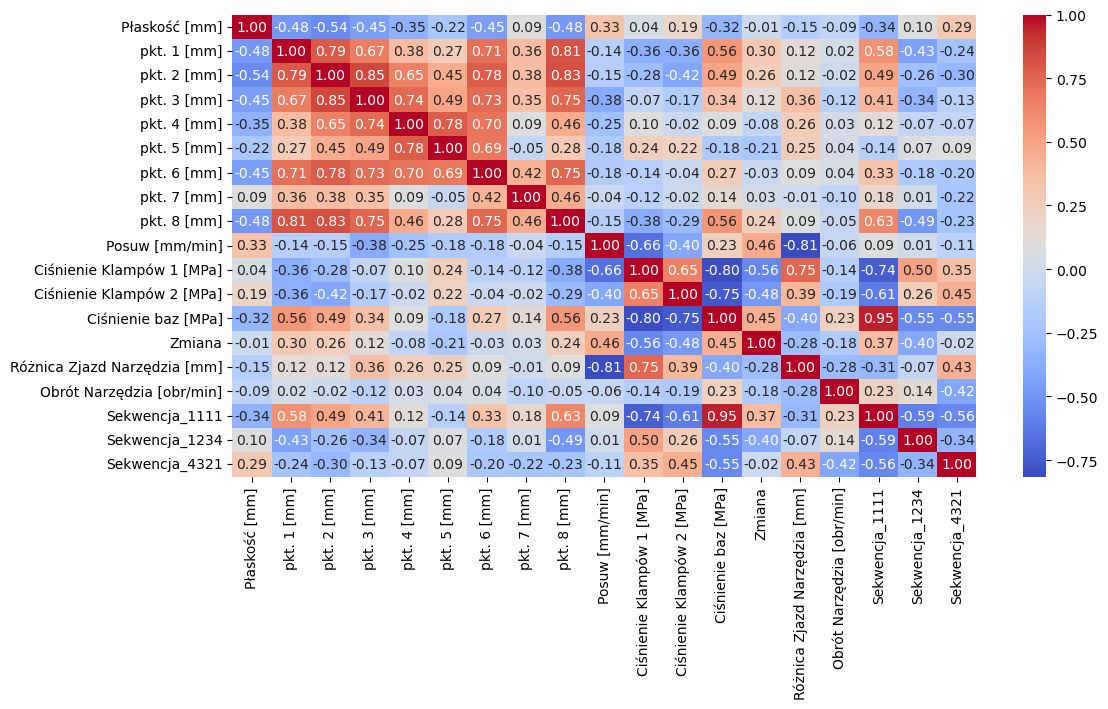

In [6]:
plt.figure(figsize=(12,6))
sns.heatmap(df_final.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

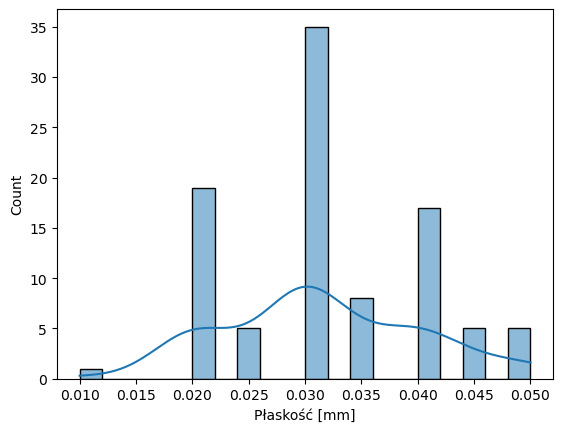

In [7]:
sns.histplot(df_final["Płaskość [mm]"], bins=20, kde=True)
plt.show()

pokazac outliery jako boxplot

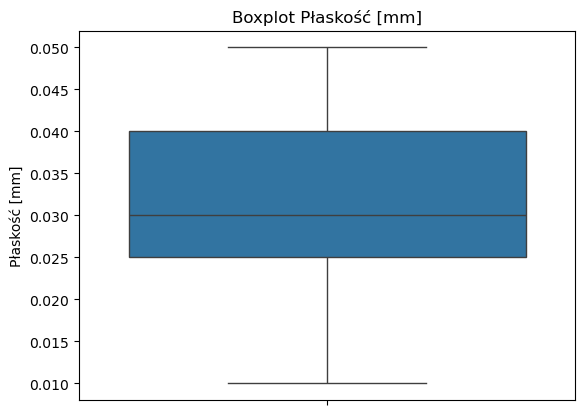

In [8]:
sns.boxplot(data=df_final, y="Płaskość [mm]")
plt.title("Boxplot Płaskość [mm]")
plt.show()

usuniecie outliery, wszystko mozna uzywac co bylo na wykladzie.

In [9]:
# Выбираем только числовые признаки для определения выбросов
X_numeric = df_final.select_dtypes(include=['float64', 'int64'])

# Обучаем модель IsolationForest
iso_forest = IsolationForest(contamination=0.05, random_state=42)  # contamination — доля выбросов
outliers = iso_forest.fit_predict(X_numeric)

# Добавим столбец с информацией о выбросах
df_final['Outlier'] = outliers

# outliers == -1 → выброс, 1 → нормальное наблюдение
df_cleaned = df_final[df_final['Outlier'] == 1].drop(columns=['Outlier'])

print(f"Ilość outlierów: {(outliers == -1).sum()}")
print(f"Rozmiar oczyszczonego zbioru danych: {df_cleaned.shape}")

Ilość outlierów: 5
Rozmiar oczyszczonego zbioru danych: (90, 19)


po usunieciu outlierow, przerobic jeszcze raz regresja i klasyfikacja

In [10]:
X = df_cleaned.drop(columns=["Płaskość [mm]"])
y = df_cleaned["Płaskość [mm]"]

2. regressor

In [11]:
categorical_features = ["Sekwencja_1111", "Sekwencja_1234", "Sekwencja_4321", "Zmiana"]
numeric_features = [col for col in X.columns if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'  # Остальные признаки оставить как есть
)

In [12]:
# Список моделей
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Linear Regression': LinearRegression(),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'KNN Regressor': KNeighborsRegressor(n_neighbors=5),
    'SVR': SVR()
}

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print("X_train columns:", X_train.columns.tolist())
print("Categorical features:", categorical_features)

X_train columns: ['pkt. 1 [mm]', 'pkt. 2 [mm]', 'pkt. 3 [mm]', 'pkt. 4 [mm]', 'pkt. 5 [mm]', 'pkt. 6 [mm]', 'pkt. 7 [mm]', 'pkt. 8 [mm]', 'Posuw [mm/min]', 'Ciśnienie Klampów 1 [MPa]', 'Ciśnienie Klampów 2 [MPa]', 'Ciśnienie baz [MPa]', 'Zmiana', 'Różnica Zjazd Narzędzia [mm]', 'Obrót Narzędzia [obr/min]', 'Sekwencja_1111', 'Sekwencja_1234', 'Sekwencja_4321']
Categorical features: ['Sekwencja_1111', 'Sekwencja_1234', 'Sekwencja_4321', 'Zmiana']


In [14]:
results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    
    results[name] = {
        'y_pred': y_pred,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'MAE': mae,
        'MAPE': mape,
        'CV Scores': cv_scores,
        'CV Mean': np.mean(cv_scores),
        'Model': pipe
    }

In [15]:
for name, metrics in results.items():
    print(f"Model: {name}")
    print(f"Średni błąd kwadratowy (MSE): {metrics['MSE']:.2f}")
    print(f"Pierwiastek średniego błędu kwadratowego (RMSE): {metrics['RMSE']:.2f}")
    print(f"Współczynnik determinacji (R²): {metrics['R2']:.2f}")
    print(f"Średni błąd bezwzględny (MAE): {metrics['MAE']:.2f}")
    print(f"Średni procentowy błąd bezwzględny (MAPE): {metrics['MAPE']:.2f}")
    # print(f"Przewidywane wartości: {metrics['y_pred']}")
    print(f"Średni R² w walidacji krzyżowej (CV Mean): {metrics['CV Mean']:.2f}")
    print(f"R² w walidacji krzyżowej: {metrics['CV Scores']}")
    print()

Model: Random Forest
Średni błąd kwadratowy (MSE): 0.00
Pierwiastek średniego błędu kwadratowego (RMSE): 0.01
Współczynnik determinacji (R²): 0.46
Średni błąd bezwzględny (MAE): 0.00
Średni procentowy błąd bezwzględny (MAPE): 0.14
Średni R² w walidacji krzyżowej (CV Mean): -0.09
R² w walidacji krzyżowej: [-0.10584014 -1.07757143  0.29202     0.22622091  0.21343   ]

Model: Linear Regression
Średni błąd kwadratowy (MSE): 0.00
Pierwiastek średniego błędu kwadratowego (RMSE): 0.01
Współczynnik determinacji (R²): 0.37
Średni błąd bezwzględny (MAE): 0.01
Średni procentowy błąd bezwzględny (MAPE): 0.19
Średni R² w walidacji krzyżowej (CV Mean): -0.11
R² w walidacji krzyżowej: [ 0.42709261  0.15752389  0.07531093 -0.31918307 -0.89703787]

Model: Gradient Boosting
Średni błąd kwadratowy (MSE): 0.00
Pierwiastek średniego błędu kwadratowego (RMSE): 0.01
Współczynnik determinacji (R²): 0.47
Średni błąd bezwzględny (MAE): 0.01
Średni procentowy błąd bezwzględny (MAPE): 0.15
Średni R² w walidacji k

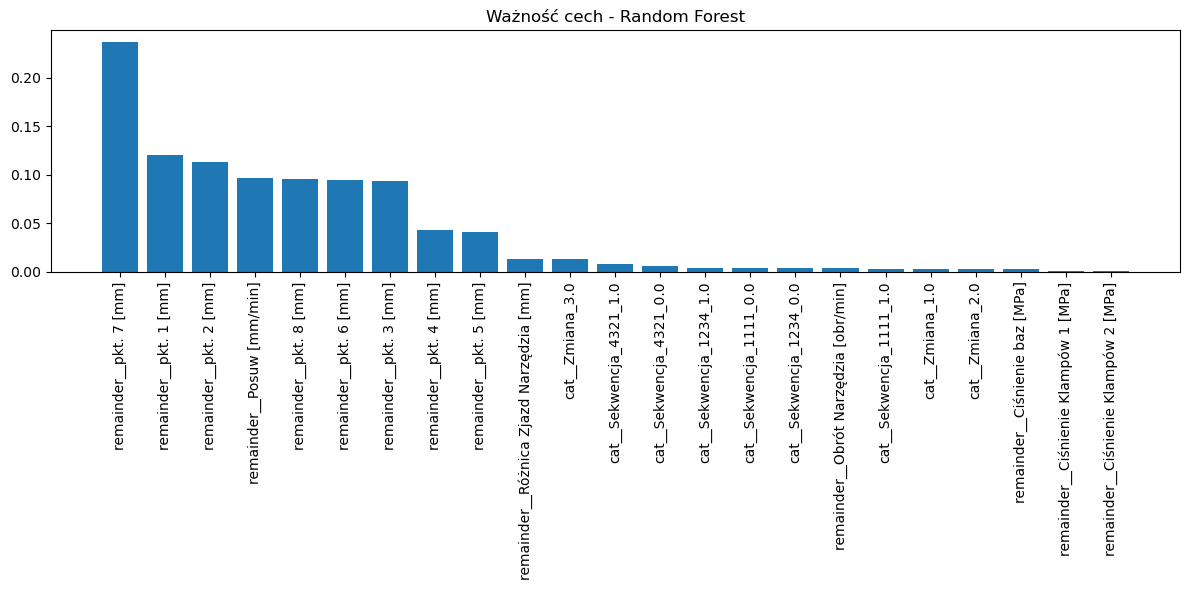

In [16]:
# Выбор модели
model_name = 'Random Forest'
model = results[model_name]['Model']  # Это Pipeline

# Список признаков после one-hot и passthrough
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

# Получаем важности признаков
importances = model.named_steps['regressor'].feature_importances_
indices = np.argsort(importances)[::-1]

# Визуализация
plt.figure(figsize=(12, 6))
plt.title(f"Ważność cech - {model_name}")
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

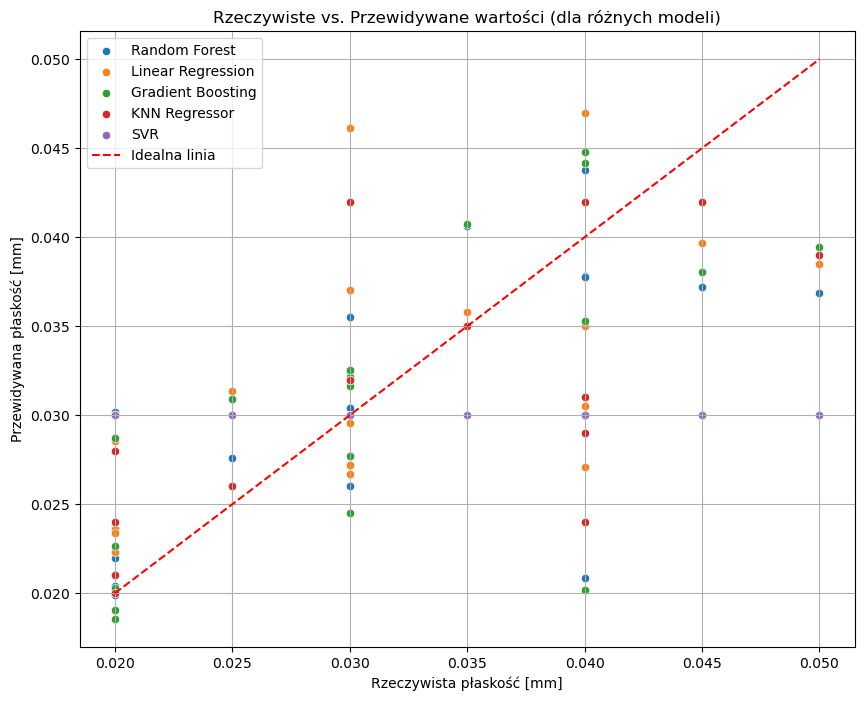

In [17]:
plt.figure(figsize=(10, 8))

for name, metrics in results.items():
    sns.scatterplot(x=y_test, y=metrics['y_pred'], label=name)

# Линия идеального предсказания
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Idealna linia')

plt.xlabel("Rzeczywista płaskość [mm]")
plt.ylabel("Przewidywana płaskość [mm]")
plt.title("Rzeczywiste vs. Przewidywane wartości (dla różnych modeli)")
plt.legend()
plt.grid(True)
plt.show()

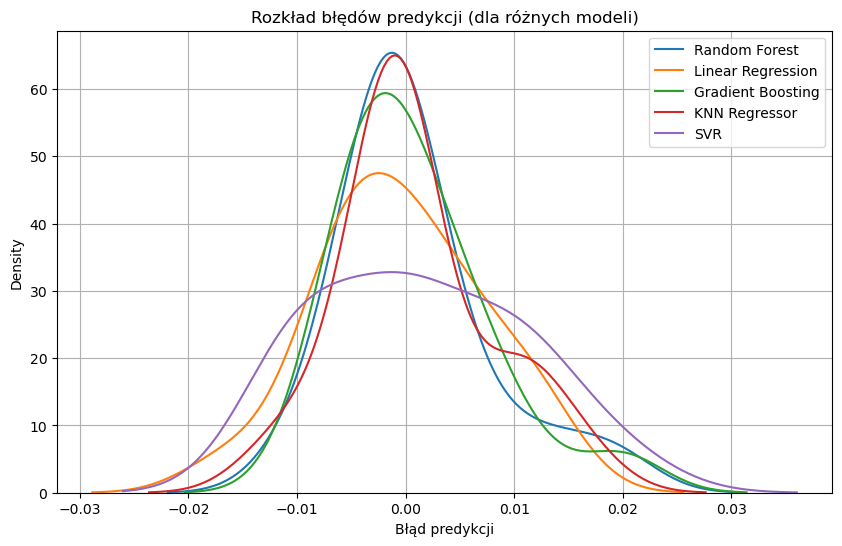

In [18]:

plt.figure(figsize=(10, 6))

for name, metrics in results.items():
    residuals = y_test - metrics['y_pred']
    sns.kdeplot(residuals, label=name)

plt.title("Rozkład błędów predykcji (dla różnych modeli)")
plt.xlabel("Błąd predykcji")
plt.legend()
plt.grid(True)
plt.show()

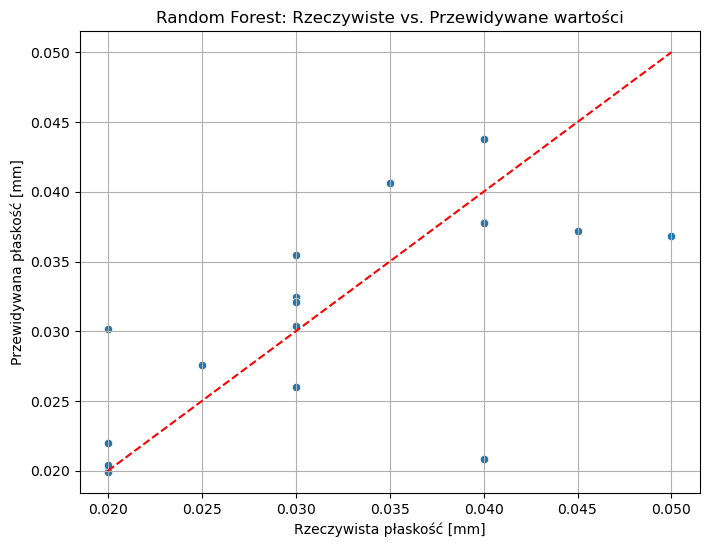

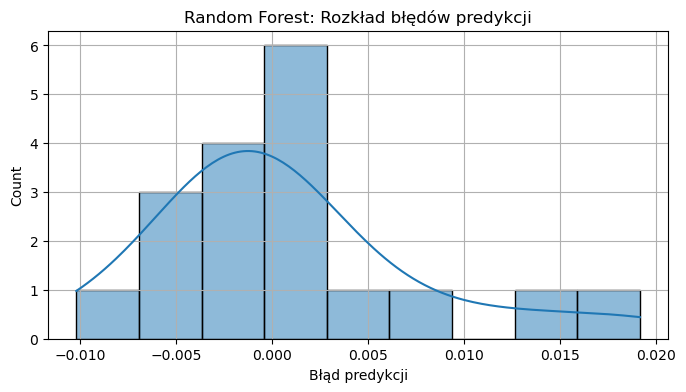

In [19]:
model_name = "Random Forest"
y_pred = results[model_name]['y_pred']

# Rzeczywiste vs. Przewidywane wartości
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Rzeczywista płaskość [mm]")
plt.ylabel("Przewidywana płaskość [mm]")
plt.title(f"{model_name}: Rzeczywiste vs. Przewidywane wartości")
plt.grid(True)
plt.show()

# Rozkład błędów predykcji
residuals = y_test - y_pred
plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True)
plt.title(f"{model_name}: Rozkład błędów predykcji")
plt.xlabel("Błąd predykcji")
plt.grid(True)
plt.show()


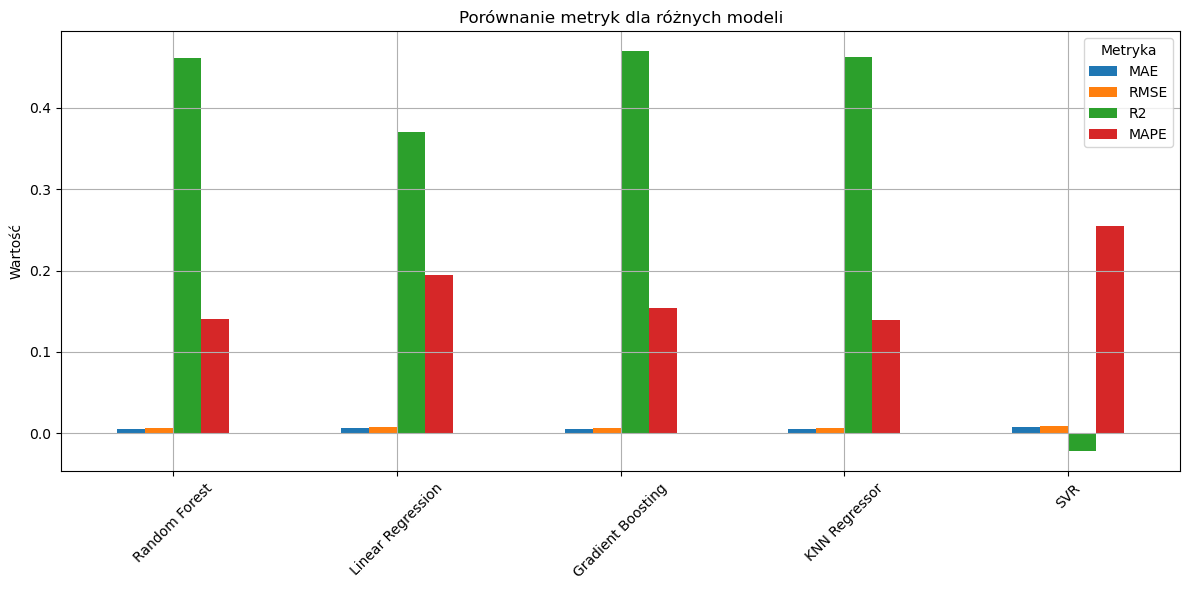

In [20]:
# Собираем метрики в DataFrame
metrics_df = pd.DataFrame({
    model: {
        'MAE': values['MAE'],
        'RMSE': values['RMSE'],
        'R2': values['R2'],
        'MAPE': values['MAPE']
    }
    for model, values in results.items()
}).T  # Транспонируем

# Строим графики
metrics_df.plot(kind='bar', figsize=(12, 6), grid=True)
plt.title("Porównanie metryk dla różnych modeli")
plt.ylabel("Wartość")
plt.xticks(rotation=45)
plt.legend(title="Metryka")
plt.tight_layout()
plt.show()

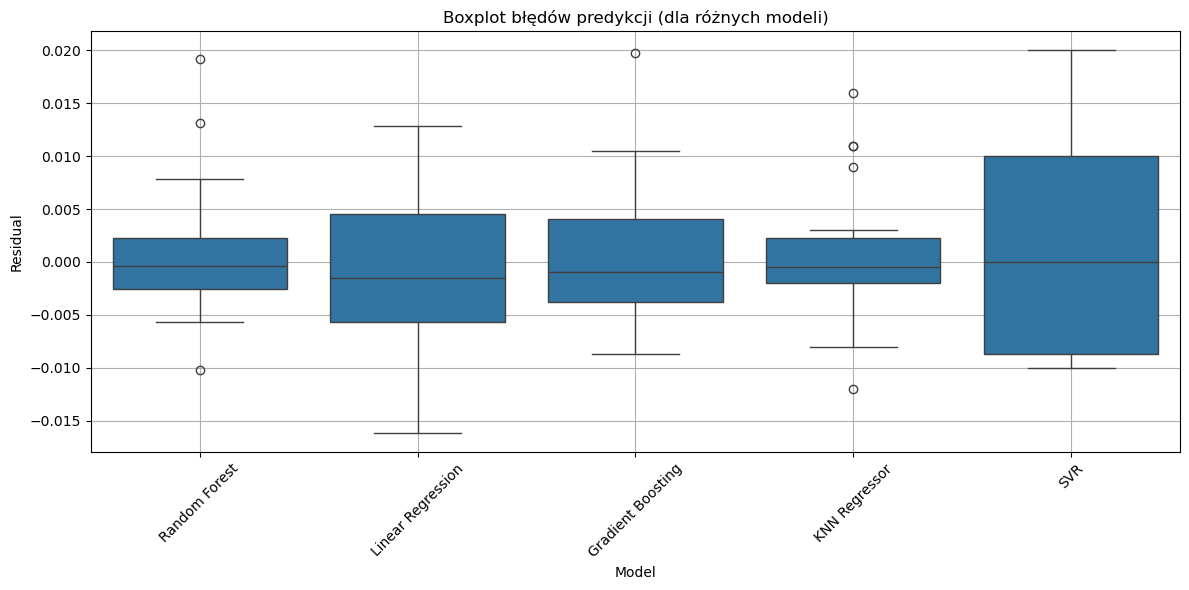

In [21]:
# Собираем ошибки в один DataFrame
residuals_data = []

for model, values in results.items():
    residuals = y_test - values['y_pred']
    for res in residuals:
        residuals_data.append({'Model': model, 'Residual': res})

residuals_df = pd.DataFrame(residuals_data)

plt.figure(figsize=(12, 6))
sns.boxplot(x='Model', y='Residual', data=residuals_df)
plt.title("Boxplot błędów predykcji (dla różnych modeli)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

2. sprobowac potraktowac jako klasyfikacja i ocenic klasyfikacje

In [22]:
# Ensure bins are strictly increasing
last_bin = max(0.1, df_cleaned["Płaskość [mm]"].max()) + 1e-6
bins = [0, 0.05, 0.1, last_bin]
labels = ["niska", "średnia", "wysoka"]
df_cleaned["Płaskość_kategoria"] = pd.cut(df_cleaned["Płaskość [mm]"], bins=bins, labels=labels)
print(df_cleaned)

X = df_cleaned.drop(columns=["Płaskość [mm]", "Płaskość_kategoria"])
y_class = df_cleaned["Płaskość_kategoria"]

    Płaskość [mm]  pkt. 1 [mm]  pkt. 2 [mm]  pkt. 3 [mm]  pkt. 4 [mm]  \
0           0.050         0.00        -0.04        -0.04        -0.09   
1           0.030         0.00        -0.04        -0.04        -0.08   
2           0.040         0.00        -0.04        -0.05        -0.09   
3           0.035         0.00        -0.05        -0.05        -0.08   
4           0.035        -0.02        -0.05        -0.05        -0.07   
..            ...          ...          ...          ...          ...   
90          0.030         0.02         0.00         0.00        -0.04   
91          0.040         0.02         0.00         0.05         0.01   
92          0.030         0.03        -0.01         0.00        -0.03   
93          0.030         0.02        -0.01         0.00        -0.04   
94          0.040         0.03        -0.01         0.00        -0.03   

    pkt. 5 [mm]  pkt. 6 [mm]  pkt. 7 [mm]  pkt. 8 [mm]  Posuw [mm/min]  \
0         -0.10       -0.060        0.070        

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

model_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=42)
model_clf.fit(X_train, y_train)
y_pred_clf = model_clf.predict(X_test)

print(confusion_matrix(y_test, y_pred_clf))
print(classification_report(y_test, y_pred_clf))


[[18]]
              precision    recall  f1-score   support

       niska       1.00      1.00      1.00        18

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



d:\conda\envs\jupyter\Lib\site-packages\sklearn\metrics\_classification.py:409: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
